# `Approches semi-supervisées`

__`En semi‑supervisé`__, les approches par graphe à propagation de labels représentent les données comme un graphe de similarité et diffusent les labels connus vers les nœuds non étiquetés.
sosososo
:::
__`Idée de base de l'approche semi-supervisée simple itérative`__
 - Chaque exemple est un nœud, les arêtes encodent la similarité (k‑NN, RBF sur la distance, etc.).
 - Les nœuds labellisés ont des labels fixés, les nœuds non labellisés reçoivent une distribution de labels.
 - À chaque itération, les distributions se mettent à jour par moyenne pondérée des voisins, 
 - Ceci correspond à une marche aléatoire/clamping sur le graphe.
 - On converge vers une solution où les labels varient « doucement » sur le graphe (hypothèse de manifold) 
:::
`Comparaison : `
0. modèle supervisé simple 
1. self-training : simple/itératif
2. propagation label
    
`0. Modèle supervisé simple (baseline)`
- on entraîne un classifieur classique (logreg, SVM, réseau, etc.) uniquement sur les données labellisées.
- les données non labellisées sont ignorées.
- la perf est limitée par la quantité de labels ; c’est la référence pour jauger si l'impacte SSL.   

`1. Self‑training simple / itératif`
Utiliser le modèle supervisé comme “Evaluateur” pour s’auto‑alimenter avec des pseudo‑labels prédits.

__Principe (pseudo‑labelling itératif) :__
 - Entraîner un modèle supervisé sur les données labellisées uniquement (peu de données labellisées).
 - Prédire les labels du non‑labellé, garder seulement les prédictions à forte confiance (ex. proba > 0.9).
 - Ajouter ces exemples pseudo‑labellés au jeu de train, réentraîner.
 - Répéter 2–3 jusqu’à convergence ou plus rien de suffisamment confiant.

 - `Caractéristiques :`
   __Mécanisme :__  
    - Cadre “modèle supervisé avec un jeu de train qui augmente”, l’architecture du modèle ne change pas.
   __Avantages :__  
    - Facile à plugger sur n’importe quel modèle (CNN, Transformer, etc.).
    - Peut dépasser nettement le baseline si le modèle de départ est déjà raisonnablement bon.
   __Inconvénients :__  
    - Risque d’amplifier les erreurs (confirmation biaisée) si les pseudo‑labels sont mauvais.
    - Sensible aux seuils de confiance, à l’ordre d’ajout des exemples, etc.

`2. LabelPropagation`
Au lieu de réentraîner un modèle à chaque itération, on définit un graphe de similarité sur toutes les données et on “diffuse” les labels des points labellisés vers les autres.

__Principe (graphe fixe) :__
 - Construire un graphe d’affinité W sur tous les points (RBF, k‑NN…).
 - Initialiser un vecteur de labels Y : labels one‑hot pour les points annotés, “inconnu” pour les autres.
 - Itérer une mise à jour de type Y←SY avec S dérivé de W, en gardant les labels des points annotés fixes.
 - À la convergence, affecter à chaque nœud la classe de proba maximale.

 - `Caractéristiques :`
    __Mécanisme :__ 
    - utilisation explicite de la structure géométrique/manifold via le graphe ; pas de “vrai” modèle paramétrique global si l'on s’en tient au LP pur.
   __Avantages :__
    - Très bon quand le graphe est bien clusterisé (clusters compacts, bien séparés) et peu de labels.
    - Pas besoin de choisir une architecture ; peu de paramètres (kernel, gamma, k).
   __Inconvénients :__
    - Dépend fortement du graph building (choix de k, gamma RBF, métrique).
    - Peut être coûteux en mémoire pour de très gros jeux (graphe dense).
    - Sur des données très haute dimension/complexes, LP seul est souvent moins bon que self‑training + modèle riche.



 Aspect | Supervised simple | Self‑training | LabelPropagation |
| --- | --- | --- | --- |
| Utilise le non‑labellé ? | Non | Oui, via pseudo‑labels | Oui, via graphe de similarité |
| Mécanisme clé | Entraînement une fois sur les données labellisées uniquement | Ré‑entraînement itératif avec ajout progressif de pseudo‑labels sûrs | Diffusion des labels sur un graphe de similarité fixé |
| Où est la “structure” ? | Apprise uniquement à partir des points labellisés | Apprise par le modèle, enrichie par les pseudo‑labels générés | Imposée par la construction du graphe (RBF, k‑NN, métrique) |
| Avantage typique | Simplicité, stabilité, peu de sources d’erreur | Fort gain possible si le modèle initial est déjà raisonnablement bon | Efficace avec très peu de labels si le graphe reflète bien les clusters |
| Risque principal | Sous‑apprentissage si très peu de labels | Auto‑renforcement d’erreurs (pseudo‑labels faux) | Propagation globale d’erreurs si le graphe est mal construit |

Dans la version “classique” de LabelPropagation (type scikit‑learn), la mise à jour se fait comme une moyenne pondérée des labels voisins, pondérée par les poids du graphe.

Formule (intuitive)
$$ y_i^{(t+1)}=\sum_j S_{ij}y^{(t)} \text{, avec } S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}} $$
On note : 
- $W_{ij}$ le poids de l’arête entre les nœuds i et j (affinité, issue de ton RBF ou k‑NN). 
- $y_{jy}$ le vecteur de scores de labels au nœud j (une coordonnée par classe).

`1. Graphe et labels initiaux`: 
 - Nœud 1:label connu Rouge, Nœud 5:label connu Bleu, Nœuds 2,3,4 : non étiquetés.   
`Arêtes pondérées (symétriques)` :  
  - $w_{1,2}=1$, $w_{1,2}=1$, $w_{2,3}=0,5$, $w_{2,3}=0,5$, $w_{3,4}=1$, $w_{3,4}=1$, $w_{4,5}=1$, $w_{4,5}=1$.  
`Sommes/nœud` : 
 - $\small \sum_k W_{1k}=1,5$, $\small \sum_k W_{2k}=1+0,5=1,5$, $\small \sum_k W_{3k}=0,5+1=2$, $\small \sum_k W_{4k}=1+1=2$, $\small \sum_k W_{5k}=1$.  
`Donc :`
  - $S_{2,1}=1/1,5=2/3\text{ , }S_{2,3}=0,5/1,5=1/3\text{ , }S_{2,1}=0,5/1,5=1/3\text{ , }S_{3,4}=1/1,5=2/3\text{ , }S_{4,3}=1/2\text{ , }S_{4,5}=1/2$ ..
`2. Représenter les labels comme vecteurs`
On a 2 classes, on code chaque nœud par un vecteur $(p_R,p_B)$ :
- Nœud 1 (R connu) : (1,0)
- Nœud 5 (B connu) : (0,1)
- Nœuds 2,3,4 (inconnus) : initialement (0,0) ou, pour être neutre, (0,5,0,5). 
- Prenons (0,0) et on ré‑injecte les labels connus à chaque itération.
`3. Une itération de propagation`
Version simple : 
- pour les nœuds non étiquetés, on fait la moyenne pondérée des voisins ; 
- pour les nœuds étiquetés (1 et 5), on les remet à leur label initial après la mise à jour.
__Itération t=0→t=1__
 - Nœud 1 : reste (1,0) (source).
 - Nœud 5 : reste (0,1).
 - Nœud 2 : voisins 1 et 3

    - Label de 1 : (1,0)
    - Label de 3 : (0,0)
    - Poids normalisés : $S_{2,1}=\frac{2}{3}\text{ , } S_{2,3}=\frac{1}{3}\text{ => }y_2^{(1)}=\frac{2}{3}(1,0)+\frac{1}{3}(0,0)=(\frac{2}{3},0)$
 - Nœud 3 : voisins 2 et 4, mais au temps 0 ils sont (0,0), donc $y_{3}^{(1)}=(0,0)$.
 - Nœud 4 : voisins 3 et 5.
   - Label de 3 : (0,0)
   - Label de 5 : (0,1)
   - Poids : $S_{4,3}=\frac{1}{2}\text{ , } S_{4,5}=\frac{1}{2}\text{ => } y_{4}^{(1)}=\frac{1}{2}(0,0)+ \frac{1}{2}(0,1)=(0, \frac{1}{2})$

`Après 1 itération :` 
 - $ y_1 =(1,0) \text{ , } y_2≈(0.67,0) \text{ , } y_2≈(0.67,0) \text{ , } y_3=(0,0) \text{ , }y_4=(0,0.5) \text{ , } y_5=(0,1)$
 - On voit déjà la `“zone rouge”` se diffuser vers 2 et la “zone bleue” vers 4.
`4. Itération suivante (esquisse)`
Itération $t=1→t=2$ (toujours en gardant 1 et 5 fixés) :
 - Nœud 2 : voisin 1 (R fort) et 3 (encore neutre)→ reste très proche de rouge.
 - Nœud 3 : voisins 2 (devenu rouge) et 4 (bleu)

   - $S_{3,2}=\frac{1}{3}\text{ , }S_{3,4}=\frac{2}{3}\text{ => }y_3^{(2)}=\frac{1}{3}y_2^{(1)}+ \frac{2}{3}y_4^{(1)}≈ \frac{1}{3}(0.67,0)+ \frac{2}{3}(0,0.5)≈(0,22,0.33)$
   - Donc 3 devient “mixte”, légèrement plus bleu que rouge.

Si on continue ces itérations, on obtient un champ de labels “lissé” entre les sources 1 (Rouge) et 5 (Bleu). Le nœud 2 finira fortement rouge, 4 fortement bleu, 3 au milieu en probas intermédiaires.

En pratique, l’algorithme sur graphe fixe fait exactement ce type de diffusion itérative, avec souvent une formulation matricielle 
 - $Y^{(t + 1)}=\alpha SY^{(t)} + (1−\alpha)Y(0)$ pour conserver fermement les labels connus.   


In [ ]:
import numpy as np
from sklearn.semi_supervised import LabelPropagation

# 5 points sur une ligne en 1D (on peut les embedder en 2D si on veut)
# dans un vrai problème, X serait ton vecteur de features (MFCC, pixels, embeddings, etc.).
X = np.array([[0.0],[1.0],[2.0],[3.0],[4.0]])

# labels : 1 = R, 5 = B, les autres inconnus
# on code R=0, B=1 pour scikit-learn
y = np.array([0, -1, -1, -1, 1])

label_prop = LabelPropagation(kernel="knn", n_neighbors=2, max_iter=1000)
# une matrice d’affinité W à partir de X (RBF ou k‑NN selon kernel),
label_prop.fit(X, y)
y_propag = label_prop.transduction_
print("Labels propagés (0=R, 1=B) :", y_propag)

Labels propagés (0=R, 1=B) : [0 0 0 0 1]


`Le modèle construit son propre graphe d’affinité à partir de X`
__kernel="rbf"__.  
sklearn construit en interne le graphe de similarité à partir de X et propage les labels des nœuds y != -1.
Les poids sont donnés par un noyau gaussien sur les distances $W_{ij}=exp(−γ||x_i−x_j||^2)$
 - Plus $x_i$ et $x_j$ sont proches en norme euclidienne, plus W_{ij} est grand.
 - Plus ils sont loin, plus $W_{ij}$ tend vers 0.
 - gamma contrôle l’échelle : grand gamma → noyau très local, petit gamma → plus global.

__kernel="knn"__
Les poids viennent du graphe k‑plus proches voisins :
 - On trouve pour chaque point ses n_neighbors plus proches en distance euclidienne.
 - On crée une matrice de voisinage (souvent binaire) :

$$W_{ij} = \begin{cases} 1, & \text{si } x_j \text{ est parmi les k plus proches voisins de } x_i \text{ (ou vice-versa)},\\ 0, & \text{sinon.} \end{cases}$$
 - Puis on symétrise (grosso modo $W←(W+W^⊤)/2)$.

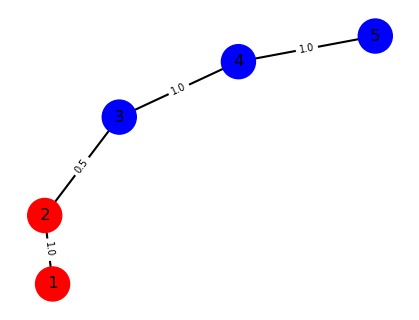

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
edges = [(1, 2, 1.0),(2, 3, 0.5),(3, 4, 1.0),(4, 5, 1.0),]
G.add_weighted_edges_from(edges)
pos = nx.spring_layout(G,seed=0)  # placement automatique

labels_nodes = {1: 'R', 5: 'B'}  # connus
# admettons qu’après propagation l'on ait :
labels_propag = {1: 'R', 2: 'R', 3: 'B', 4: 'B', 5: 'B'}
labels = nx.get_edge_attributes(G, 'weight')

color_map = []
for n in G.nodes():
    if labels_propag[n] == 'R':
        color_map.append('red')
    else:
        color_map.append('blue')

plt.figure(figsize=(4, 3))  
nx.draw(G, pos, with_labels=True, node_color=color_map, width=1.5, node_size=600)
nx.draw_networkx_edge_labels(G, pos, font_size=7, edge_labels=labels)
plt.axis('off')
plt.show()


:::
__`Deux variantes classiques (sklearn.semi_supervised)`__

`LabelPropagation (propage les labels des points étiquetés vers les non étiquetés)`
- Un petit sous‑ensemble de nœuds a un label connu, les autres sont marqués comme inconnus 
- À chaque itération, chaque nœud met à jour son vecteur de labels 
- Il prend une combinaison (moyenne pondérée) des labels voisins, pondérée par les poids de l’arête.
- On garde fixes les labels des nœuds initialement étiquetés, et on itère jusqu’à convergence.
- À la fin, chaque nœud est assigné à la classe de probabilité maximale dans son vecteur de labels.

__`Rôle du graphe d’affinité (RBF / k‑NN)`__
- La structure des données par une matrice de similarité représentée par W, par exemple :
- kernel RBF : $W_{ij}=exp(−γ ||x_i−x_j||^2)$ (dense, pondérée finement).
- graphe k‑NN relie chaque point à ses k plus proches voisins, avec un poids de 1 ~ f(distance (sparse)).

Ce graphe est fixé pendant tout l’algorithme : on ne modifie pas les arêtes ni les poids, on ne fait que diffuser les labels sur cette structure.

- Graphe d’affinité fixé (kernel rbf ou knn).
 - Les labels des nœuds labellisés sont clampés (non modifiés) et diffusent aux autres.

`LabelSpreading`
 - Utilise la Laplacienne normalisée et une « soft clamping » des labels (les labels des nœuds labellisés peuvent légèrement bouger, plus robuste au bruit).
::: 

## Récupération des données

In [3]:
%matplotlib inline

In [ ]:
#%pip -q install -U numba

Note: you may need to restart the kernel to use updated packages.


In [1]:
import umap
umap.UMAP(verbose=True, n_neighbors=15, n_components=2, random_state=42, low_memory=True)

,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [2]:
import umap
import sklearn
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pds

In [3]:
sklearn.__version__

'1.7.1'

In [5]:
sns.set_theme(context="paper", style="white")

%time mnist = fetch_openml("mnist_784", version=1)#,return_X_y=True)

CPU times: user 1.7 s, sys: 385 ms, total: 2.08 s
Wall time: 2.15 s


In [ ]:
"""
import umap
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric="euclidean",
    random_state=42,   # pour la reproductibilité
)
subset_size = 10000

data = reducer.fit_transform(mnist.data)
"""

/Users/asriel/miniconda3/envs/env_pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [100]:
data = mnist.data
mnist["target"] = mnist["target"].astype(int)
target = mnist["target"]

# check que les données sont déjà mélangées
print(target.values[:10])

[5 0 4 1 9 2 1 3 1 4]


In [101]:
subset_ratio = 0.15 # on ne prend pas tout pour aller plus vite
train_ratio = 0.9  # on entraine sur % du subset
labelled_ratio = 0.1 # et on utilise qu'une partie des labels (semi-sup)

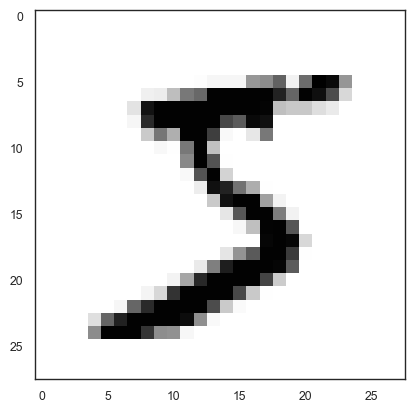

In [102]:
def plot(data,instance):
    plt.imshow(data.iloc[instance].values.reshape(28,28),cmap="Greys")
    
plot(data,0)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, stratify=target, random_state=0, 
    train_size=train_ratio*subset_ratio, 
    test_size=(1-train_ratio)*subset_ratio
)

In [104]:
print(f'len(X_train): {len(X_train)} len(X_test) : {len(X_test)} ')  

len(X_train): 9450 len(X_test) : 1050 


## Modèle supervisé complet

  + KNN simple 
  + CNN 

In [105]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

#model = KNeighborsClassifier(n_neighbors=3)
model = SVC(kernel="rbf", gamma=0.5, probability=True)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print("Accuracy %.3f"%acc)


Accuracy 0.112


In [12]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.semi_supervised import LabelSpreading, LabelPropagation

## Modèle self-trained

<Axes: >

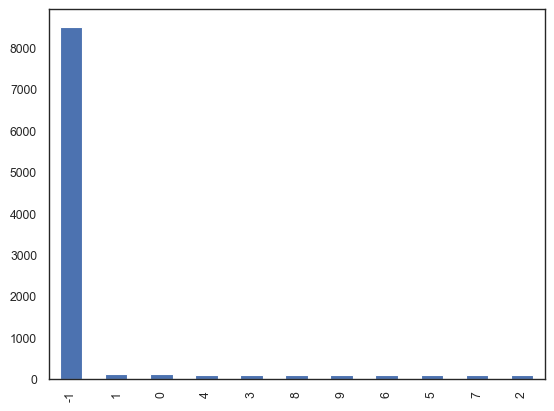

In [13]:
labelled_ratio = 0.1 # combien d'exemples avec labels ? -> 


# le modèle considèrera qu'un label -1 veut dire pas de label
y_labelled = np.copy(y_train)
y_labelled[int(labelled_ratio*len(y_train)):] = -1
counts = pds.Series(y_labelled).value_counts()
counts.plot(kind="bar")

## Exercice 

sur le modèle du notebook avec Selftraining / Labelpropagation

- entrainez un modèle de K plus proches voisins sur la projection faite par UMAP
- appliquer le selftraining ou une propagation de labels

Accuracy 0.868


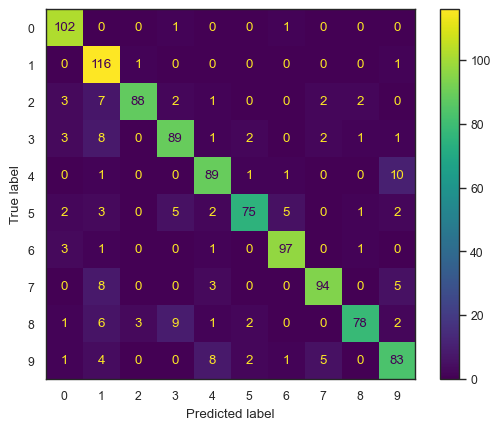

In [ ]:
# on compare à entrainement sur la petite base supervisée
model_base = KNeighborsClassifier(n_neighbors=3)
model_base.fit(X_train[y_labelled!=-1],y_labelled[y_labelled!=-1])
y_pred = model_base.predict(X_test)
acc = accuracy_score(y_pred,y_test)

print("Accuracy %.3f"%acc)
cm = confusion_matrix(y_test, y_pred, labels=model_base.classes_)

cmplot = ConfusionMatrixDisplay(cm)
cmplot.plot() 

In [33]:
# Quels paramètres seraient la même chose que d'annoter tout le train avec les predictions faites par le modèle ? 
# NB: ici parametres par défaut de la class selftraining
model_base = KNeighborsClassifier(n_neighbors=3)
st = SelfTrainingClassifier(model_base,
                            threshold = 0.75,
                            criterion="threshold",
                            #criterion="k_best",
                            #k_best=10,
                            max_iter=10).fit(X_train,y_labelled)

In [34]:
y_pred = st.predict(X_test)
acc = accuracy_score(y_pred,y_test)

print("Accuracy %.3f"%acc)

Accuracy 0.917


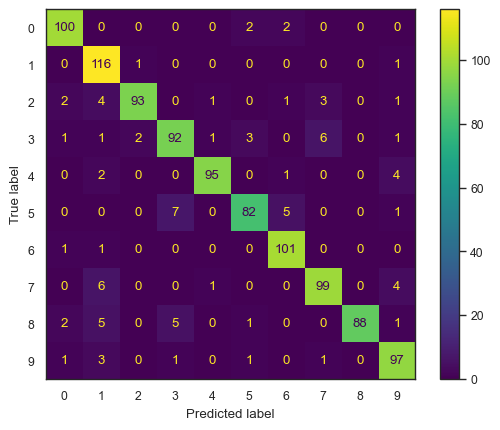

In [35]:
cm = confusion_matrix(y_test, y_pred, labels=st.classes_)


cmplot = ConfusionMatrixDisplay(cm)
cmplot.plot()
plt.show() 


## Propagation de label

In [70]:
ls = LabelSpreading(kernel="knn",alpha=0.2)
ls = LabelPropagation(kernel="knn",n_neighbors=7)
ls.fit(X_train,y_labelled)

,kernel,'knn'
,gamma,20
,n_neighbors,7
,max_iter,1000
,tol,0.001
,n_jobs,None


In [63]:
y_pred = ls.predict(X_test)

In [64]:
y_pred

array([9, 9, 8, ..., 1, 5, 4])

In [65]:
acc = accuracy_score(y_pred,y_test)

print("Accuracy %.3f"%acc)

Accuracy 0.914


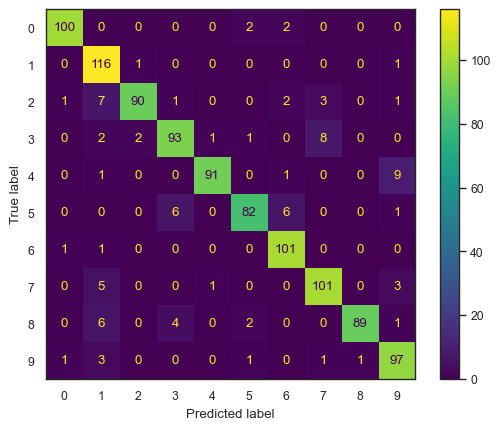

In [66]:
cm = confusion_matrix(y_test, y_pred, labels=ls.classes_)


cmplot = ConfusionMatrixDisplay(cm)
cmplot.plot()
plt.show() 

## Variantes

- Essayer d'améliorer les performances
- Essayer avec LabelPropagation

In [67]:
help(LabelPropagation)

Help on class LabelPropagation in module sklearn.semi_supervised._label_propagation:

class LabelPropagation(BaseLabelPropagation)
 |  LabelPropagation(kernel='rbf', *, gamma=20, n_neighbors=7, max_iter=1000, tol=0.001, n_jobs=None)
 |  
 |  Label Propagation classifier.
 |  
 |  Read more in the :ref:`User Guide <label_propagation>`.
 |  
 |  Parameters
 |  ----------
 |  kernel : {'knn', 'rbf'} or callable, default='rbf'
 |      String identifier for kernel function to use or the kernel function
 |      itself. Only 'rbf' and 'knn' strings are valid inputs. The function
 |      passed should take two inputs, each of shape (n_samples, n_features),
 |      and return a (n_samples, n_samples) shaped weight matrix.
 |  
 |  gamma : float, default=20
 |      Parameter for rbf kernel.
 |  
 |  n_neighbors : int, default=7
 |      Parameter for knn kernel which need to be strictly positive.
 |  
 |  max_iter : int, default=1000
 |      Change maximum number of iterations allowed.
 |  
 |  t